# **<font color="red">Compare Perceptron Trick & Sklearn Logistic Regression</font>**

Perceptron learned bias: -0.10000000000000003
Perceptron learned weights: [ 0.07061018 -0.06882265]
Perceptron train accuracy: 98.57%
Perceptron test accuracy: 97.33%

LogisticRegression test accuracy: 99.33%
LogisticRegression weights (coef): [[ 1.50264608 -0.85652421]]
LogisticRegression bias (intercept): [-0.53750207]


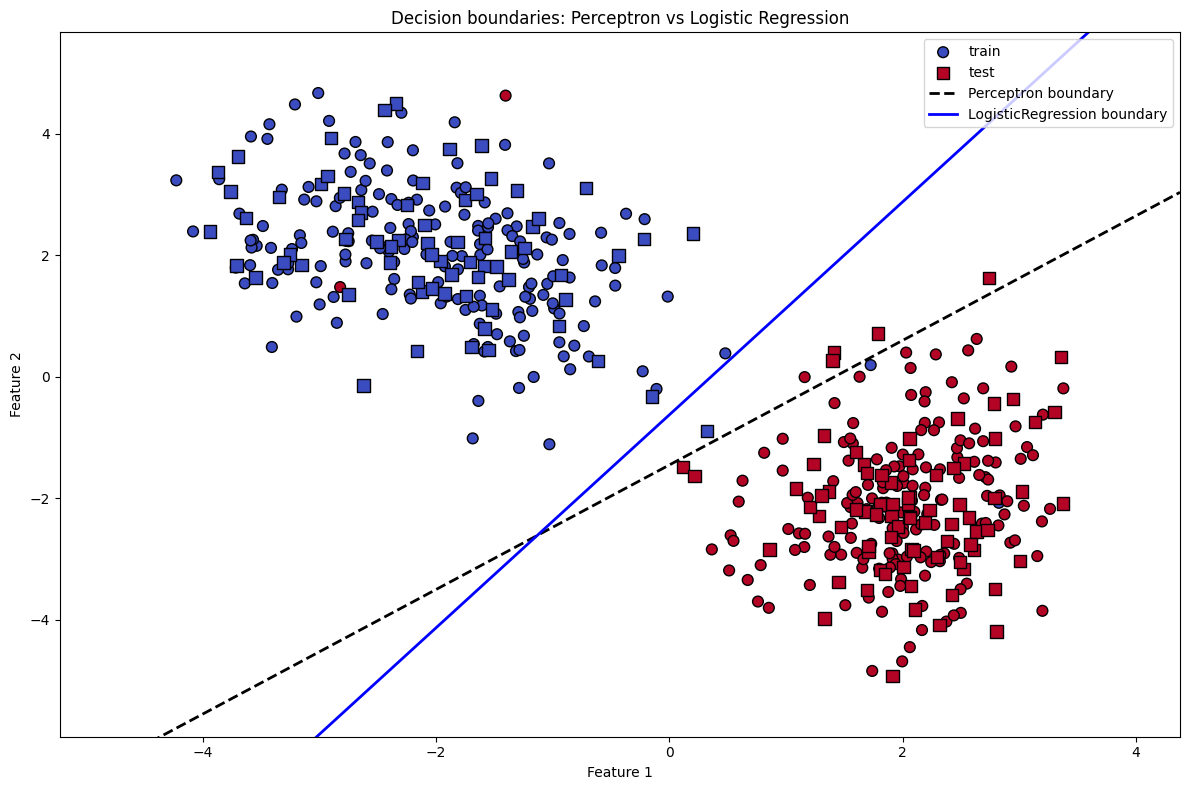

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ---------------------------
# Perceptron (simple online)
# ---------------------------
def perceptron(X_train, y_train, lr=0.1, epochs=1000, shuffle=True):
    """
    Online perceptron algorithm for binary classification with labels {0,1}.
    
    This implements the classic perceptron learning rule, an early foundational
    algorithm in machine learning for finding linear separators in feature space.
    It updates weights iteratively based on misclassification errors, converging
    when no updates are needed (i.e., all points are correctly classified).
    
    Parameters:
    -----------
    X_train : array-like, shape (n_samples, n_features)
        Training features.
    y_train : array-like, shape (n_samples,)
        Binary target labels (0 or 1).
    lr : float, default=0.1
        Learning rate for weight updates.
    epochs : int, default=1000
        Maximum number of training epochs.
    shuffle : bool, default=True
        Whether to shuffle samples at the start of each epoch.
    
    Returns:
    --------
    bias : float
        Learned bias term.
    w : ndarray, shape (n_features,)
        Learned weight vector for features.
    full_weights : ndarray, shape (n_features + 1,)
        Full weight vector including bias as the first element.
    
    Notes:
    ------
    - Assumes linearly separable data for convergence.
    - Uses a step activation function: sign(0) = 1.
    - In deep learning contexts, this is a precursor to more advanced models like MLPs.
    """
    X = np.asarray(X_train, dtype=float)
    y = np.asarray(y_train, dtype=int).ravel()
    n_samples, n_features = X.shape
    
    # Augment features with bias column (all 1s) to handle bias in dot product
    Xb = np.insert(X, 0, 1.0, axis=1)  # shape (n_samples, n_features + 1)
    
    # Initialize weights: bias + feature weights
    weights = np.zeros(n_features + 1, dtype=float)
    
    for epoch in range(int(epochs)):
        # Create index array for samples
        idx = np.arange(n_samples)
        if shuffle:
            # Shuffle for stochastic-like updates, improving generalization
            np.random.shuffle(idx)
        
        updates = 0  # Track misclassifications for early stopping
        
        for i in idx:
            xi = Xb[i]  # Current augmented sample
            yi = int(y[i])  # True label
            
            # Compute linear score: w^T * x
            score = float(np.dot(xi, weights))
            
            # Apply step function for prediction (hard threshold at 0)
            y_hat = 1 if score >= 0 else 0
            
            # Compute error (residual)
            err = yi - y_hat
            
            if err != 0:
                # Update rule: w += lr * err * x (perceptron update)
                weights += lr * err * xi
                updates += 1
        
        # Early stopping if no misclassifications (convergence)
        if updates == 0:
            break
    
    # Extract bias and weights for return
    bias = float(weights[0])
    w = weights[1:].copy()
    return bias, w, weights.copy()


def perceptron_predict(X_test, weights_full):
    """
    Predict binary labels using the trained perceptron weights.
    
    Applies the linear decision boundary defined by the weights.
    
    Parameters:
    -----------
    X_test : array-like, shape (n_samples, n_features) or (n_features,)
        Test features; supports single sample as 1D array.
    weights_full : ndarray, shape (n_features + 1,)
        Full weights including bias as first element.
    
    Returns:
    --------
    predictions : ndarray, shape (n_samples,)
        Predicted labels (0 or 1).
    """
    X = np.asarray(X_test, dtype=float)
    if X.ndim == 1:
        # Handle single sample input
        X = X.reshape(1, -1)
    
    # Augment with bias column
    Xb = np.insert(X, 0, 1.0, axis=1)
    
    # Compute scores and threshold at 0
    scores = Xb.dot(weights_full)
    return (scores >= 0).astype(int)


# ---------------------------
# Helper: safe linear boundary plot
# ---------------------------
def plot_linear_boundary(ax, w_full, x_min, x_max, y_min, y_max, label, color='k', linestyle='--', linewidth=2):
    """
    Plot the linear decision boundary defined by w0 + w1*x + w2*y = 0.
    
    Handles edge cases like near-vertical lines to avoid division by zero.
    Useful for visualizing separators in 2D feature space for models like perceptron or logistic regression.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        Axis object to plot on.
    w_full : ndarray, shape (3,)
        Weights [bias, w1, w2] for 2D features.
    x_min, x_max : float
        X-axis limits for plotting.
    y_min, y_max : float
        Y-axis limits for plotting.
    label : str
        Legend label for the boundary line.
    color : str, default='k'
        Line color.
    linestyle : str, default='--'
        Line style.
    linewidth : float, default=2
        Line width.
    """
    w0, w1, w2 = float(w_full[0]), float(w_full[1]), float(w_full[2])
    eps = 1e-9  # Small epsilon for numerical stability
    
    if abs(w2) > eps:
        # Non-vertical line: solve for y in terms of x
        x_vals = np.array([x_min, x_max])
        y_vals = -(w0 + w1 * x_vals) / w2
        ax.plot(x_vals, y_vals, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    elif abs(w1) > eps:
        # Near-vertical line: solve for x in terms of y (constant x)
        xv = -w0 / w1
        ax.plot([xv, xv], [y_min, y_max], label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    else:
        # Degenerate case (e.g., zero weights): no line plotted
        pass


# ---------------------------
# Main: dataset, train, compare
# ---------------------------
def main(random_state=41):
    """
    Main execution function: Generate dataset, train models, evaluate, and visualize.
    
    Demonstrates perceptron vs. logistic regression on a synthetic 2D binary classification task.
    Highlights differences in decision boundaries and performance.
    
    Parameters:
    -----------
    random_state : int, default=41
        Seed for reproducibility in data generation.
    """
    np.random.seed(random_state)
    
    # Generate synthetic 2D dataset for binary classification
    # Parameters tuned for linear separability with some noise
    X, y = make_classification(
        n_samples=500, 
        n_features=2, 
        n_informative=2, 
        n_redundant=0,
        n_classes=2, 
        n_clusters_per_class=1, 
        random_state=random_state, 
        class_sep=2.0
    )
    
    # Split into train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # Train Perceptron
    p_bias, p_w, p_weights_full = perceptron(
        X_train, y_train, lr=0.1, epochs=1000, shuffle=True
    )
    print("Perceptron learned bias:", p_bias)
    print("Perceptron learned weights:", p_w)
    
    # Evaluate Perceptron accuracy
    train_preds_p = perceptron_predict(X_train, p_weights_full).ravel()
    test_preds_p = perceptron_predict(X_test, p_weights_full).ravel()
    train_acc_p = np.mean(train_preds_p == y_train)
    test_acc_p = np.mean(test_preds_p == y_test)
    print(f"Perceptron train accuracy: {train_acc_p*100:.2f}%")
    print(f"Perceptron test accuracy: {test_acc_p*100:.2f}%")
    
    # Train Logistic Regression (probabilistic linear classifier)
    lr_model = LogisticRegression()  # Default: L2 regularization, 'lbfgs' solver
    lr_model.fit(X_train, y_train)
    
    # Evaluate Logistic Regression
    y_pred_lr = lr_model.predict(X_test)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f"\nLogisticRegression test accuracy: {acc_lr*100:.2f}%")
    print("LogisticRegression weights (coef):", lr_model.coef_)
    print("LogisticRegression bias (intercept):", lr_model.intercept_)
    
    # Compute plot limits with padding for visibility
    pad = 1.0
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot training and test data points
    # Use 'coolwarm' colormap for binary classes (0: blue, 1: red)
    ax.scatter(
        X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', 
        marker='o', edgecolor='k', s=60, label='train'
    )
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', 
        marker='s', edgecolor='k', s=80, label='test'
    )
    
    # Plot Perceptron decision boundary (dashed black)
    plot_linear_boundary(
        ax, p_weights_full, x_min, x_max, y_min, y_max,
        label='Perceptron boundary', color='black', linestyle='--', linewidth=2
    )
    
    # Prepare and plot Logistic Regression boundary (solid blue)
    log_bias = float(lr_model.intercept_.ravel()[0])
    log_w = lr_model.coef_.ravel()
    log_weights_full = np.array([log_bias, log_w[0], log_w[1]])
    plot_linear_boundary(
        ax, log_weights_full, x_min, x_max, y_min, y_max,
        label='LogisticRegression boundary', color='blue', linestyle='-', linewidth=2
    )
    
    # Set axis limits and labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title("Decision boundaries: Perceptron vs Logistic Regression")
    ax.legend(loc='upper right')
    
    # Adjust layout and display plot
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()